# Single FCM Edge-List Quality Control

## Purpose

This notebook validates one aligned Functional Connectivity Matrix (FCM) edge-list file from the Curvature-FCN-Aging dataset.

The validation checks the raw file format, data types, rows, nodes, ROI pairs, missing values, and correlation range.

The final result will be a compact quality-control summary stating whether the selected FCM file passes validation.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from lemon_connectivity.alignment import align_participants_to_fcm
from lemon_connectivity.io import (
    edge_list_to_matrix,
    load_fcm_edge_list,
    summarize_fcm_edge_list,
)


## Data source

The FCM files are stored in the Curvature-FCN-Aging dataset. The cohort information file contains the participant IDs used for alignment.

In [2]:
# Define the folder containing the FCM files
fcm_data = Path("../data/external/Curvature-FCN-Aging/DATA/FCM")

# Define the cohort metadata file
cohort_path = Path("../data/external/Curvature-FCN-Aging/DATA/cohort_information.tsv")

# Load cohort metadata
We load the cohort information with sub_id as a string so that participant identifiers are preserved exactly.

In [3]:

# Load the cohort metadata
cohort_metadata = pd.read_csv(
    cohort_path,
    sep="\t",
    dtype={"sub_id": "string"},
)

# Align participants with FCM files
The existing alignment function checks which cohort participants have corresponding FCM files.

The alignment result will be used to select the FCM file reproducibly.

In [4]:
# Align cohort participants with the available FCM files
alignment_result = align_participants_to_fcm(
    cohort_metadata,
    fcm_data)

## Select one aligned FCM file reproducibly

The shared alignment pipeline identifies valid one-to-one participant/file
matches. Matched records are sorted by canonical ID and filename, and the first
record is selected. This selection rule is deterministic without hard-coding or
displaying a participant identifier.

In [5]:
matched_records = alignment_result.alignment_table.loc[
    alignment_result.alignment_table["alignment_status"] == "matched"
].sort_values(
    ["canonical_id", "matrix_filename"],
    kind="stable")

if matched_records.empty:
    raise ValueError("No one-to-one participant/FCM matches are available")

selected_matrix_path = matched_records.iloc[0]["matrix_path"]
if pd.isna(selected_matrix_path):
    raise ValueError("The selected matched record has no matrix path")

target_file_path = Path(str(selected_matrix_path))
if not target_file_path.is_file():
    raise FileNotFoundError("The deterministically selected FCM file is unavailable")

## Load and validate the edge list

The shared loader verifies the complete file rather than inspecting only a few
rows. It enforces the three named columns and numeric data types, then checks:

- 19,900 rows
- 200 unique ROI nodes with the exact index set 0–199
- no self-edges or duplicate unordered pairs
- upper-triangle ordering (`roi_i < roi_j`)
- complete coverage of all expected unordered ROI pairs
- no missing or non-finite values
- Pearson correlations within −1 to +1

The loader raises a descriptive error if any check fails. Only the aggregate QC
table is displayed; raw participant-level rows and the selected filename remain
hidden.

In [6]:
edge_table = load_fcm_edge_list(target_file_path, n_rois=200)
edge_table

,roi_i,roi_j,correlation
0,9,109,0.911632
1,19,121,0.906548
2,9,108,0.902196
3,44,149,0.885611
4,108,112,0.882266
...,...,...,...
19895,44,81,-0.631550
19896,44,61,-0.632517
19897,61,154,-0.640387
19898,92,149,-0.654442


## Produce the QC summary table

The validation results are presented as a compact table showing the
expected value, observed value, and whether each quality-control check
passes.

In [7]:
qc_summary = summarize_fcm_edge_list(edge_table, n_rois=200)
qc_summary


,check,expected,observed,passed
0,Edge columns,"['roi_i', 'roi_j', 'correlation']","['roi_i', 'roi_j', 'correlation']",True
1,Edge rows,19900,19900,True
2,ROI data types,integer,"int64, int64",True
3,Correlation data type,numeric,float64,True
4,Unique nodes,200,200,True
5,ROI index set,0-199,0-199,True
6,Self-edges,0,0,True
7,Duplicate unordered pairs,0,0,True
8,Upper-triangle ordering,19900/19900 rows with roi_i < roi_j,19900/19900 rows,True
9,Complete unordered pairs,19900,19900,True


## Biological interpretation of one edge

Consider the **synthetic** example `(roi_i=12, roi_j=57,
correlation=0.42)`. It represents a Pearson correlation of 0.42 between the
resting-state BOLD time series of two Schaefer cortical parcels in one
participant.

A positive value means the two regional signals tend to vary together; a
negative value means they tend to vary in opposite directions; and a value near
zero indicates little linear co-variation. Functional connectivity is a
statistical association and does not by itself demonstrate a direct anatomical
connection or a causal relationship.

## Final validation status

The FCM file passes validation only if all required quality-control checks pass.

The final status is determined automatically from the validation report.

In [8]:
validation_passed = bool(qc_summary["passed"].all())
if not validation_passed:
    failed_checks = qc_summary.loc[~qc_summary["passed"], "check"].tolist()
    raise AssertionError(f"Single-file FCM QC failed: {failed_checks}")

final_status = pd.Series(
    {
        "status": "PASS",
        "checks_passed": int(qc_summary["passed"].sum()),
        "checks_total": len(qc_summary),
    },
    name="single_fcm_qc",
)
final_status.to_frame()

,single_fcm_qc
status,PASS
checks_passed,13
checks_total,13


## Conclusion

A final status of `PASS` means the deterministically selected file contains a
complete, valid Schaefer-200 upper-triangle edge list: all 19,900 unique ROI
pairs are present, ROI indices and correlation values satisfy the documented
constraints, and no self-edges, duplicates, missing values, or non-finite
correlations were detected. Any discrepancy instead stops the notebook with the
failed check named explicitly.

# Reconstruct the 200 × 200 matrix

The edge list stores each undirected ROI pair once. The shared `edge_list_to_matrix()` helper places each correlation in both `M[i, j]` and `M[j, i]` and assigns `1.0` to the diagonal.

In [15]:
fc_matrix = edge_list_to_matrix(
    edge_table,
    n_rois=200,
)

assert fc_matrix.shape == (200, 200)

print("Matrix shape:", fc_matrix.shape)

Matrix shape: (200, 200)


## Check matrix symmetry and diagonal

For an undirected functional-connectivity matrix, the correlation between
ROI *i* and ROI *j* must be the same as the correlation between ROI *j*
and ROI *i*. Therefore, the matrix must be symmetric.

The diagonal represents each ROI correlated with itself and should contain
`1.0` for every ROI.

These assertions verify that the reconstructed matrix has the expected
network structure before visualization.

In [16]:
assert np.allclose(fc_matrix, fc_matrix.T)
assert np.allclose(np.diag(fc_matrix), 1.0)


## Check matrix values

The reconstructed matrix should contain only finite numerical values.
This check confirms that no missing (`NaN`) or infinite (`+∞` or `−∞`)
values are present before visualization.

In [14]:
assert np.isfinite(fc_matrix).all()


## Visualize the functional-connectivity matrix

The 200 × 200 matrix is displayed as a heatmap.

The color scale is fixed from −1 to +1 because Pearson correlation
coefficients lie within this range. This makes the colors directly
interpretable:

- Positive correlations are greater than 0.
- Values near 0 indicate weak or little linear association.
- Negative correlations are less than 0.

The diagonal is 1.0 and therefore represents each ROI's correlation
with itself.

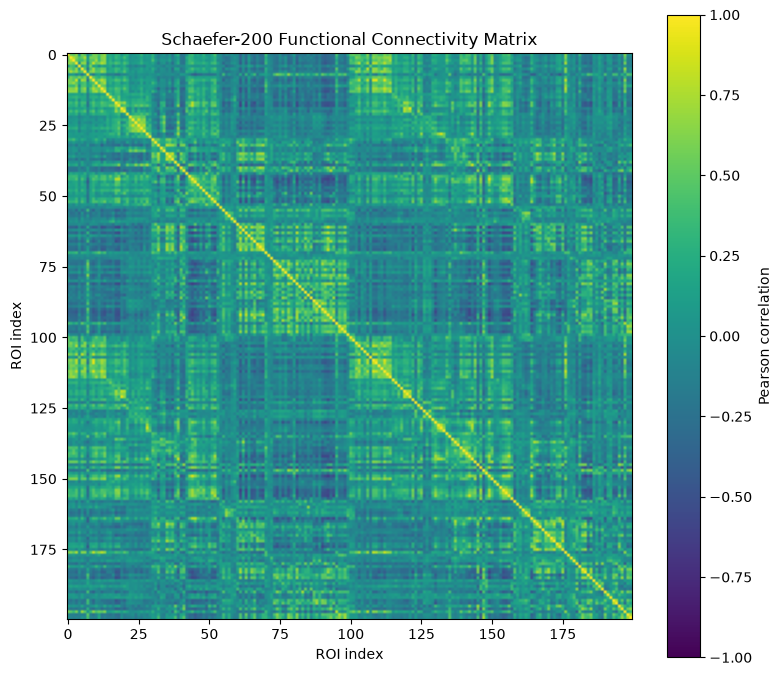

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

plt.imshow(
    fc_matrix,
    vmin=-1,
    vmax=1,
    aspect="equal",
)

plt.colorbar(label="Pearson correlation")
plt.xlabel("ROI index")
plt.ylabel("ROI index")
plt.title("Schaefer-200 Functional Connectivity Matrix")

plt.tight_layout()
plt.show()

## Visualize the off-diagonal edge distribution

The diagonal contains self-correlations of `1.0` and is excluded from this
plot.

The histogram therefore shows the distribution of the 19,900 unique
off-diagonal functional-connectivity edges.

Positive values indicate positive linear co-variation between two ROI
time series, values near zero indicate weak linear association, and
negative values indicate negative linear co-variation.

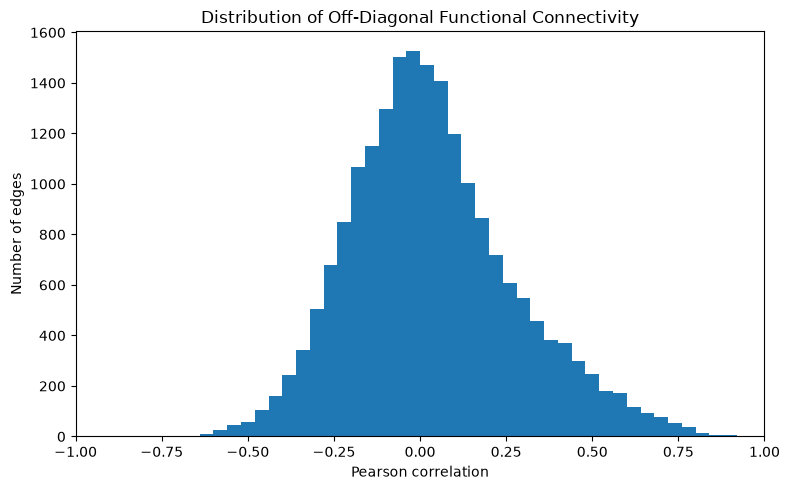

In [13]:
off_diagonal_edges = fc_matrix[np.triu_indices_from(fc_matrix, k=1)]

plt.figure(figsize=(8, 5))

plt.hist(
    off_diagonal_edges,
    bins=50,
    range=(-1, 1),
)

plt.xlabel("Pearson correlation")
plt.ylabel("Number of edges")
plt.title("Distribution of Off-Diagonal Functional Connectivity")

plt.xlim(-1, 1)
plt.tight_layout()
plt.show()


## Conclusion

The validated FCM edge list was successfully reconstructed into a
200 × 200 functional-connectivity matrix.

All structural assertions passed:

- the matrix has the expected 200 × 200 dimensions;
- the matrix is symmetric;
- all diagonal values are 1.0;
- all matrix values are finite.

The heatmap uses a fixed −1 to +1 Pearson-correlation scale, allowing
positive, near-zero, and negative functional associations to be interpreted
consistently. The edge-distribution plot excludes the diagonal and therefore
represents the unique off-diagonal ROI-to-ROI connections.

These checks and visualizations confirm that the selected validated edge list
can be represented as a complete symmetric connectivity matrix for subsequent
network analyses.